# 01 — Data Exploration

In [2]:
import os
if not os.path.exists('MiniGPT'):
    !git clone https://github.com/userKk1/MiniGPT.git
%cd MiniGPT

Cloning into 'MiniGPT'...
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 17 (delta 3), reused 14 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (17/17), done.
Resolving deltas: 100% (3/3), done.
/content/MiniGPT


In [3]:
!pip install -q datasets matplotlib

In [24]:
%cd /content/MiniGPT

!sed -n '1,200p' config.py


/content/MiniGPT
# config.py

"""
Usage:
    from config import cfg
    print(cfg.model.n_layer)
"""
 
from dataclasses import dataclass, field
from pathlib import Path
 
# ---------------------------------------------------------------------------
# Paths (relative to project root, wherever the repo is cloned)
# ---------------------------------------------------------------------------
ROOT_DIR = Path(__file__).resolve().parent  # MiniGPT/
DATA_DIR = ROOT_DIR / "data"
DATA_RAW_DIR = DATA_DIR / "raw"
DATA_PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = ROOT_DIR / "results"
CHECKPOINTS_DIR = RESULTS_DIR / "checkpoints"
LOGS_DIR = RESULTS_DIR / "logs"
FIGURES_DIR = RESULTS_DIR / "figures"
 
for _d in [DATA_RAW_DIR, DATA_PROCESSED_DIR, CHECKPOINTS_DIR, LOGS_DIR, FIGURES_DIR]:
    _d.mkdir(parents=True, exist_ok=True)
 
 
# ---------------------------------------------------------------------------
# Data
# ---------------------------------------------------------------------------
@

In [4]:
import sys
sys.path.append('.')

from config import cfg, DATA_RAW_DIR
from datasets import load_dataset
import matplotlib.pyplot as plt

print(cfg.data)

DataConfig(dataset_name='bigcode/the-stack-smol', dataset_subset='data/python', max_corpus_mb=100, max_file_chars=20000, train_split=0.9, seed=1337)


## 1. Stream the dataset

In [18]:
ds = load_dataset(
    "codeparrot/codeparrot-clean",
    split="train",
    streaming=True,
)



samples = []
total_bytes = 0
TARGET_BYTES = cfg.data.max_corpus_mb * 1024 * 1024

for example in ds:
    content = example.get('content', '')
    if not content:
        continue
    if example.get("autogenerated", False):
        continue
    if len(content) > cfg.data.max_file_chars:
        continue

    samples.append(content)
    total_bytes += len(content.encode("utf-8"))
    if total_bytes >= TARGET_BYTES:
        break

print(f'Collected {len(samples)} files, {total_bytes / (1024 * 1024):.2f} MB')

Resolving data files:   0%|          | 0/54 [00:00<?, ?it/s]

Collected 19062 files, 100.01 MB


## 2. Look at file length distribution

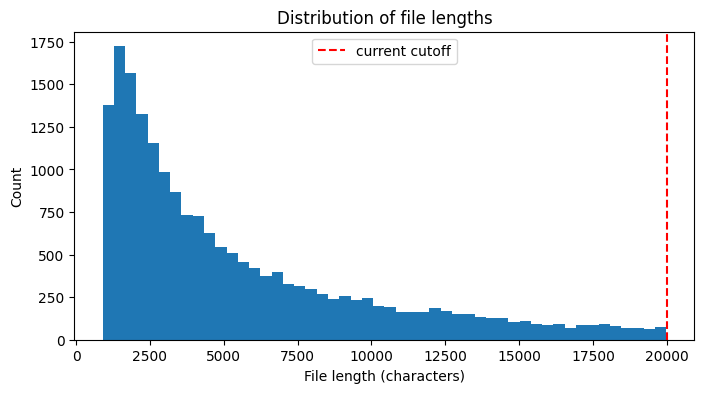

median: 3829
max: 19981
files above cutoff: 0 / 19062


In [19]:
lengths = [len(s) for s in samples]

plt.figure(figsize=(8,4))
plt.hist(lengths, bins=50)
plt.xlabel('File length (characters)')
plt.ylabel('Count')
plt.title('Distribution of file lengths')
plt.axvline(cfg.data.max_file_chars, color='red', linestyle='--', label='current cutoff')
plt.legend()
plt.show()

print('median:', sorted(lengths)[len(lengths)//2])
print('max:', max(lengths))
print(f'files above cutoff: {sum(l > cfg.data.max_file_chars for l in lengths)} / {len(lengths)}')

In [20]:
for s in samples[:3]:
    print(s[:400])
    print('-' * 60)

###############################################################################
##
##  Copyright (C) 2013-2014 Tavendo GmbH
##
##  Licensed under the Apache License, Version 2.0 (the "License");
##  you may not use this file except in compliance with the License.
##  You may obtain a copy of the License at
##
##      http://www.apache.org/licenses/LICENSE-2.0
##
##  Unless required by applicable l
------------------------------------------------------------
from itertools import chain

from django.utils.itercompat import is_iterable


class Tags:
    """
    Built-in tags for internal checks.
    """
    admin = 'admin'
    caches = 'caches'
    compatibility = 'compatibility'
    database = 'database'
    models = 'models'
    security = 'security'
    signals = 'signals'
    templates = 'templates'
    urls = 'urls'


class CheckRegistry:

    def 
------------------------------------------------------------
"""
The :mod:`sklearn.utils` module includes various utilites.
"""

from col

## 4. Character vocabulary

In [21]:
corpus_sample = ''.join(samples)
chars = sorted(set(corpus_sample))
print(f'Vocab size: {len(chars)}')
print(''.join(chars))

Vocab size: 2609
	
 !"#$%&'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[\]^_`abcdefghijklmnopqrstuvwxyz{|}~ ¡¢£¤¥§©ª«¬®¯°±²³´µ¶·¹º»¼½¾¿ÀÁÂÃÄÅÆÇÈÉÊËÌÍÎÏÐÑÒÓÔÕÖ×ØÙÚÛÜÝÞßàáâãäåæçèéêëìíîïðñòóôõö÷øùúûüýþÿāăĄąĆćČčĎďĐđēĘęĚěĞğģħīİıĹĺĽľŁłŃńŇňōőŒœŔŕŘřŚśŞşŠšŤťũŭŮůűųŸŹźŻżŽžſƃƒƛǝșɐɑɔəɹʇʊʌʤˆ˙̸̈ΈΑΒΓΔΕΖΗΘΙΚΛΜΝΞΟΠΡΣΤΥΦΧΨΩάέήίαβγδεζηθικλμνξοπρςστυφχψωόώЄІАБВГДЕЖЗИЙКЛМНОПРСТУФХЦЧШЩЪЫЬЭЮЯабвгдежзийклмнопрстуфхцчшщъыьэюяёєіїәՀաեյնրאבגדהוטילמןנסעפצקרשתآأؤإئابةتثجحخدذرزسشضطظعفقكلمنهويَّْکگیँंअआइईउएऑऔकखगचछजझटडणतथदधनपफबभमयरलवशषसह़ािीुूृेैॉोौ्२ংঅবমলসাਜਪਬਾੀੰஅஆஇஈஉஊஎஏஐஒஓஔகஙசஞடணதநனபமரறலளழஸாிீுூெேைொோௌ்ಠംമയലളാංලසහිงทนภมยษสอฮาแไ่་།ཐཕམལསིུྷစဗမာ၍ათილრუქስበባአዲᴮᴰᴳᴵᴿḋḱḿṕṱẃẌẞệἄἸῦ‌‍–—‘’‚“”„•‣…₀₁₂₃₄₅₆₇₈₉ₑₚ€ℓ№™Ω⅂←↑→↓↭↶⇀∂∆∇−∙∞∫≈≠≤≥≫⊗①②─━│┆┊┌┐└┘├┤┬┴┻┼═║╒╓╔╕╖╗╘╙╚╛╜╝╞╟╠╡╢╣╤╥╦╧╨╩╪╫╬╶╸╼╾▀▁▂▃▄▅▆▇█▉▊▋▌▍▎▏▐░▒▓▖▗▘▙▚▛▜▝▞▟■▢▣►◉○●◑◔◕◢◣◯☂☃★♂♥♦⚠⚡⚪⚫✅✓✔✗❌　、。〈〉《》『』【】あいうえおかがきぎくぐけげこごさざしじすずせぜそぞただちっつてでとどなにぬねのはばぱひびぴふぶぷへべぺほぼぽまみむめもゃやゅゆょよらりるれろわをんァアィイゥウェエォオカガキギクグケゲコゴサザシジスセタダチッツテデトドニネノバパビピフプベボマミムメュユラリルレロワンー㒅一七万三上下不与专且世业东丟两並个中串临为主丽举么义之乐乘也书买了予争事二于云互五

In [22]:
from collections import Counter

char_counts = Counter(corpus_sample)

print("Total unique characters:", len(char_counts))

print("\nTop 50:")
for char, count in char_counts.most_common(50):
    print(repr(char), count)

Total unique characters: 2609

Top 50:
' ' 24351215
'e' 7547077
't' 5182307
's' 4499449
'r' 4133644
'a' 3970548
'i' 3840248
'o' 3796112
'n' 3595404
'\n' 2959157
'l' 2929163
'd' 2258811
'c' 2025589
'p' 1905464
'f' 1849769
'_' 1843021
'u' 1792251
'm' 1704482
'.' 1663335
"'" 1317864
',' 1305593
')' 1223440
'(' 1223166
'h' 1187043
'g' 1099389
'=' 984276
'"' 897522
':' 813105
'b' 745725
'y' 713435
'#' 615725
'v' 524171
'w' 490417
'-' 464907
'T' 454649
'x' 447097
'0' 414243
'k' 404438
'E' 396392
'S' 347076
'A' 328003
'I' 312758
'N' 305604
'1' 299370
'[' 287761
']' 287413
'R' 280579
'C' 271452
'2' 229406
'O' 228744


In [23]:
total = sum(char_counts.values())

for threshold in [1, 2, 5, 10, 50, 100, 1000]:
    rare = sum(
        count <= threshold
        for count in char_counts.values()
    )

    print(
        f"Characters appearing <= {threshold} times: "
        f"{rare} / {len(char_counts)}"
    )

Characters appearing <= 1 times: 648 / 2609
Characters appearing <= 2 times: 1024 / 2609
Characters appearing <= 5 times: 1483 / 2609
Characters appearing <= 10 times: 1837 / 2609
Characters appearing <= 50 times: 2384 / 2609
Characters appearing <= 100 times: 2462 / 2609
Characters appearing <= 1000 times: 2510 / 2609
